Our Machine Learning Workflow
- Define the problem
- Load the data
- Select our inputs and target
- Split the data
- Train the model
- Make predictions
- Evaluate the model
- Test the model with a new student

Our inputs:

Input____________________What it tells the model
- LGA______________Which local government area
- Level______________Primary, JSS, or SSS
- Year_Start_________The year the data covers
- Learners___________Number of learners

Our target:

- Learner_Teacher_Ratio
This is the value we want the model to predict: the number of learners per teacher.

In [56]:
# Import necessary libraries
# Import pandas for loading and working with tabular data
# Import NumPy for numerical operations
# Import Matplotlib for creating visualisations
# Import tools needed to split the data into training and testing sets
# Import tools for handling categorical and numerical features
# Import Pipeline to combine data preprocessing and model training
# Import Linear Regression as the predictive model
# Import evaluation metrics to assess model performance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [57]:
# Load the cleaned dataset prepared specifically for the machine learning analysis

df = pd.read_csv("data/Lagos_ML_Data.csv")

print("Data loaded successfully!")

Data loaded successfully!


In [58]:
# Display the first 10 rows

df.head(10)

,LGA,Level,Year_Start,Learners,Male_Learners,Female_Learners,Female_Learners_PCT,Learner_Teacher_Ratio,Est_Teachers,LTR_Gap_vs_UBE35,Teachers_Needed_To_Meet_UBE35,Enrolment_Change_PCT_vs_Prev_Year
0,Agege,Primary,2017,17449,8569.0,8880.0,50.9,28.0,623.2,-7.0,0,-7.5
1,Ajeromi/Ifelodun,Primary,2017,24945,12297.0,12648.0,50.7,56.0,445.4,21.0,267,5.4
2,Alimosho,Primary,2017,44357,22550.0,21807.0,49.2,31.0,1430.9,-4.0,0,-0.7
3,Amuwo Odofin,Primary,2017,12767,5979.0,6788.0,53.2,46.0,277.5,11.0,87,3.5
4,Apapa,Primary,2017,8169,4157.0,4012.0,49.1,34.0,240.3,-1.0,0,-4.2
5,Badagry,Primary,2017,29920,15276.0,14644.0,48.9,49.0,610.6,14.0,244,7.9
6,Epe,Primary,2017,21404,10878.0,10526.0,49.2,42.0,509.6,7.0,102,2.7
7,Eti-Osa,Primary,2017,12691,6114.0,6577.0,51.8,46.0,275.9,11.0,87,-4.1
8,Ibeju/Lekki,Primary,2017,16880,8402.0,8478.0,50.2,47.0,359.1,12.0,123,-2.3
9,Ifako/Ijaye,Primary,2017,14690,7305.0,7385.0,50.3,23.0,638.7,-12.0,0,-5.8


In [59]:
# Check the number of rows and columns

df.shape

(180, 12)

In [60]:
# Check what the data looks like

df.describe() 

,Year_Start,Learners,Male_Learners,Female_Learners,Female_Learners_PCT,Learner_Teacher_Ratio,Est_Teachers,LTR_Gap_vs_UBE35,Teachers_Needed_To_Meet_UBE35,Enrolment_Change_PCT_vs_Prev_Year
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,2018.000000,16854.172222,8259.283333,8594.888889,51.220556,39.844444,442.244444,4.844444,87.555556,1.962778
std,0.818774,10526.051491,5301.762981,5249.226698,2.339906,14.659191,239.193958,14.659191,139.828116,7.052651
min,2017.000000,4484.000000,2238.000000,2246.000000,44.700000,17.000000,124.600000,-18.000000,0.000000,-14.600000
25%,2017.000000,9676.500000,4675.250000,5110.500000,49.800000,29.750000,281.125000,-5.250000,0.000000,-2.950000
50%,2018.000000,14191.500000,7002.000000,7360.500000,50.900000,36.000000,394.250000,1.000000,9.500000,1.650000
75%,2019.000000,19773.500000,9359.500000,10267.000000,52.425000,47.250000,510.275000,12.250000,123.000000,5.525000
max,2019.000000,58402.000000,29010.000000,29392.000000,57.700000,88.000000,1430.900000,53.000000,848.000000,31.600000


In [61]:
# Check the column names and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   LGA                                180 non-null    str    
 1   Level                              180 non-null    str    
 2   Year_Start                         180 non-null    int64  
 3   Learners                           180 non-null    int64  
 4   Male_Learners                      180 non-null    float64
 5   Female_Learners                    180 non-null    float64
 6   Female_Learners_PCT                180 non-null    float64
 7   Learner_Teacher_Ratio              180 non-null    float64
 8   Est_Teachers                       180 non-null    float64
 9   LTR_Gap_vs_UBE35                   180 non-null    float64
 10  Teachers_Needed_To_Meet_UBE35      180 non-null    int64  
 11  Enrolment_Change_PCT_vs_Prev_Year  180 non-null    float64
dtypes: fl

Select the input (X) and output (y)
- X = the information we give the model.

- y = the answer we want the model to learn.

In our case:

- X = LGA + Level + Year_Start + Learners
- y = Learner_Teacher_Ratio


In [62]:
# Select the model inputs

X = df[["LGA", "Level", "Year_Start", "Learners"]]

# Select the target to predict

y = df["Learner_Teacher_Ratio"]

In [63]:
# Check the inputs
print("Our input features (X):") 
print(X.head())

print()
print()

# Check the target
print("Our target (y):")
print(y.head())

Our input features (X):
                LGA    Level  Year_Start  Learners
0             Agege  Primary        2017     17449
1  Ajeromi/Ifelodun  Primary        2017     24945
2          Alimosho  Primary        2017     44357
3      Amuwo Odofin  Primary        2017     12767
4             Apapa  Primary        2017      8169


Our target (y):
0    28.0
1    56.0
2    31.0
3    46.0
4    34.0
Name: Learner_Teacher_Ratio, dtype: float64


#### Splitting the Data
- Training data: The model uses this data to learn.

- Testing data: We hide this data from the model and use it later to evaluate the model.

We will use:

- Training data: 2017 and 2018 (120 rows)
- Testing data: 2019 (60 rows)

In [64]:
# Use 2017 and 2018 to train the model
train_mask = df["Year_Start"] < 2019

# Use 2019 to test the model
test_mask = df["Year_Start"] == 2019

# Create the training and testing datasets
X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]


# Check the years and number of rows in each set

print("Training years:", sorted(X_train["Year_Start"].unique()))
print("Testing years:", sorted(X_test["Year_Start"].unique()))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training years: [np.int64(2017), np.int64(2018)]
Testing years: [np.int64(2019)]
Training rows: 120
Testing rows: 60


Before training, we need to convert LGA and Level from text into a format the model can understand. We'll use OneHotEncoder for that, while leaving the numerical columns as they are.

In [65]:
# Identify the text and numerical columns

categorical_features = ["LGA", "Level"]
numeric_features = ["Year_Start", "Learners"]

In [66]:
# Prepare the input columns for the model

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numeric_features)
    ]
)

In [67]:
# Create the Linear Regression model

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [68]:

# Train the model using the corrected training data
model.fit(X_train, y_train)

# Predict learner-teacher ratios for 2019
y_pred = model.predict(X_test)

In [69]:
# Display the first 10 predicted ratios
print(y_pred[:10])

[46.91767158 69.76746214 50.25072    49.30693921 58.64788782 63.52638029
 50.27864538 54.45883074 67.61498615 38.04010276]


#### Evaluate the model
Now we check how good the model actually is, using the test set it hasn't seen before, We'll use three evaluation metrics:
- MAE: The average absolute difference between actual and predicted ratios. Lower is better.
- RMSE: Similar to MAE, but penalises larger errors more heavily. Lower is better.
- R²: Indicates how well the model explains variation in the target. Closer to 1 is generally better; it can also be negative.

In [70]:
# Calculate the model's evaluation scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

MAE: 6.36
RMSE: 8.07
R²: 0.74


What each result means
- MAE = 6.36: On average, the model's predictions differ from actual learner-teacher ratios by an average of about 6.36 learners per teacher.
- RMSE = 8.07: Larger prediction errors increase this metric; it is higher than MAE, suggesting some larger errors.
- R² = 0.74: The model explains about 74% of the variation in learner-teacher ratios in the 2019 test set, relative to predicting the test-set mean.

Compare actual and predicted ratios
Now we need to put the actual values beside the predictions. This will help us identify where the model expected a different learner–teacher ratio from what was observed.

In [71]:
# Compare actual and predicted ratios for 2019

results = X_test.copy()
results["Actual_LTR"] = y_test
results["Expected_LTR"] = y_pred

# Calculate the difference between actual and expected ratios
results["Difference"] = (
    results["Actual_LTR"] - results["Expected_LTR"]
)

# Flag cases where the actual ratio is higher than expected
results["Flag"] = np.where(
    results["Difference"] > 0,
    "Worse than expected",
    "Better than or equal to expected"
)

results.head(10)

,LGA,Level,Year_Start,Learners,Actual_LTR,Expected_LTR,Difference,Flag
120,Agege,Primary,2019,16078,43.0,46.917672,-3.917672,Better than or equal to expected
121,Ajeromi/Ifelodun,Primary,2019,23682,78.0,69.767462,8.232538,Worse than expected
122,Alimosho,Primary,2019,40707,52.0,50.250720,1.749280,Worse than expected
123,Amuwo Odofin,Primary,2019,11617,61.0,49.306939,11.693061,Worse than expected
124,Apapa,Primary,2019,7116,43.0,58.647888,-15.647888,Better than or equal to expected
125,Badagry,Primary,2019,27470,57.0,63.526380,-6.526380,Better than or equal to expected
126,Epe,Primary,2019,20252,55.0,50.278645,4.721355,Worse than expected
127,Eti-Osa,Primary,2019,12829,62.0,54.458831,7.541169,Worse than expected
128,Ibeju/Lekki,Primary,2019,18479,88.0,67.614986,20.385014,Worse than expected
129,Ifako/Ijaye,Primary,2019,12428,33.0,38.040103,-5.040103,Better than or equal to expected


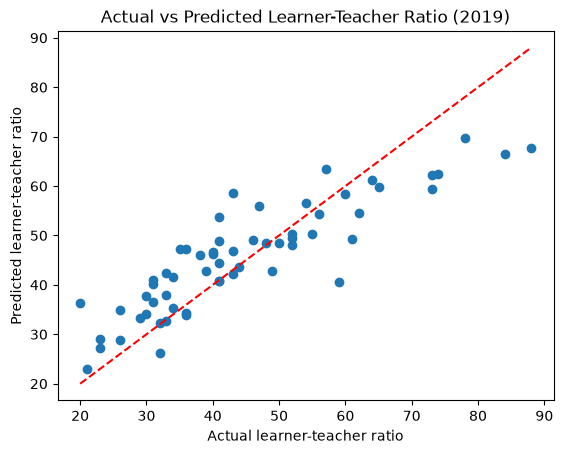

In [72]:
# Actual vs predicted (quick check)

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual learner-teacher ratio')
plt.ylabel('Predicted learner-teacher ratio')
plt.title('Actual vs Predicted Learner-Teacher Ratio (2019)')
plt.show()

This chart compares the actual learner-teacher ratios in the 2019 test set with the ratios predicted by our model. The dashed red line represents a perfect prediction (actual = predicted).
- Points close to the line = good predictions.
- Points far from the line = the model got that one wrong, in either direction.
If the model were perfect, every point would sit exactly on the red line.

- X-axis: Actual learner–teacher ratio.
- Y-axis: Predicted learner–teacher ratio.
- Red dashed line: The line where predictions would equal the actual values.
The closer a blue dot is to the red line, the more accurate that prediction is.
- Above the red line: The model predicted a higher ratio than the actual ratio.
- Below the red line: The model predicted a lower ratio than the actual ratio.
The graph shows that many predictions are reasonably close to the line, but some differ noticeably—particularly for actual ratios around 55–80. This is consistent with having some prediction errors in the test set.

How to interpret the flag
- Worse than expected: The actual ratio is higher than the model predicted, suggesting greater teacher-resource pressure than expected.
- Better than or equal to expected: The actual ratio is equal to or lower than the model predicted.

In [73]:
# Show the cases with the largest positive differences
worst_cases = results.sort_values("Difference", ascending=False)

worst_cases.head(10)

,LGA,Level,Year_Start,Learners,Actual_LTR,Expected_LTR,Difference,Flag
128,Ibeju/Lekki,Primary,2019,18479,88.0,67.614986,20.385014,Worse than expected
137,Oshodi/Isolo,Primary,2019,18682,59.0,40.565659,18.434341,Worse than expected
141,Ajeromi/Ifelodun,JSS,2019,18687,84.0,66.431037,17.568963,Worse than expected
136,Ojo,Primary,2019,27239,73.0,59.427605,13.572395,Worse than expected
123,Amuwo Odofin,Primary,2019,11617,61.0,49.306939,11.693061,Worse than expected
131,Ikorodu,Primary,2019,56310,74.0,62.357894,11.642106,Worse than expected
145,Badagry,JSS,2019,25439,73.0,62.162792,10.837208,Worse than expected
121,Ajeromi/Ifelodun,Primary,2019,23682,78.0,69.767462,8.232538,Worse than expected
127,Eti-Osa,Primary,2019,12829,62.0,54.458831,7.541169,Worse than expected
153,Lagos Island,JSS,2019,7039,49.0,42.873862,6.126138,Worse than expected


One important distinction: these are the cases most above expected, not necessarily the 10 worst cases against the UBE standard. We'll keep those two interpretations separate.


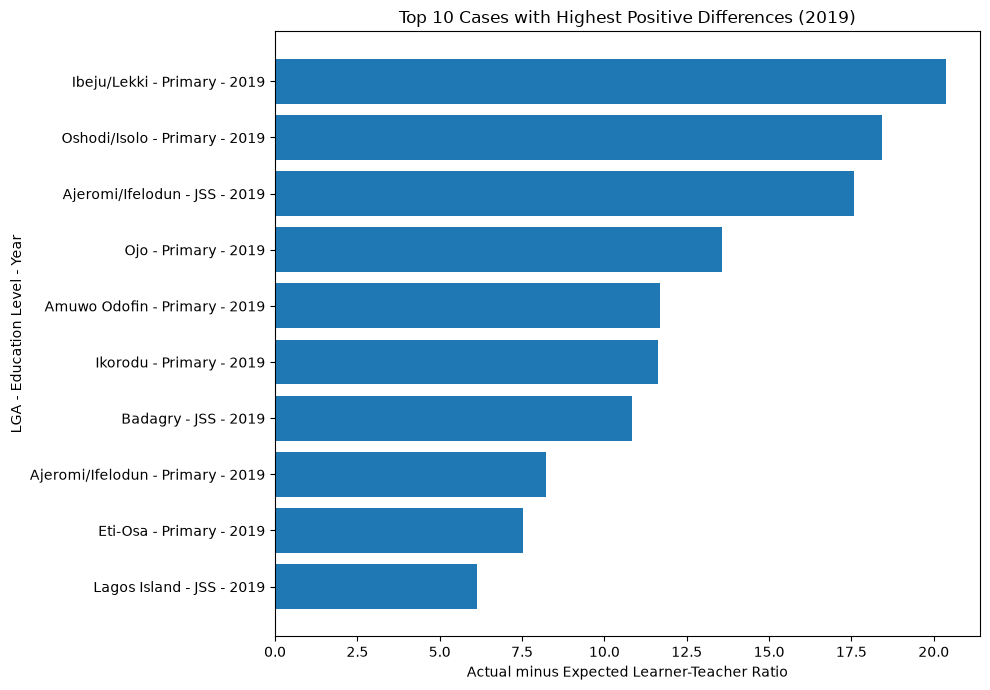

In [74]:
# Select the 10 cases with the largest positive differences
top_cases = worst_cases.head(10).copy()

# Create labels that identify each LGA, level and year
top_cases["LGA_Level_Year"] = (
    top_cases["LGA"] + " - " +
    top_cases["Level"] + " - " +
    top_cases["Year_Start"].astype(str)
)

# Plot the 10 cases
plt.figure(figsize=(10, 7))
plt.barh(
    top_cases["LGA_Level_Year"],
    top_cases["Difference"]
)

plt.xlabel("Actual minus Expected Learner-Teacher Ratio")
plt.ylabel("LGA - Education Level - Year")
plt.title("Top 10 Cases with Highest Positive Differences (2019)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### What the chart tells us

- Ibeju/Lekki – Primary has the largest positive difference, at approximately 20.39 learners per teacher.
- Oshodi/Isolo – Primary follows, at approximately 18.43.
- Ajeromi/Ifelodun – JSS is next, at approximately 17.57.
- Ojo – Primary has a difference of approximately 13.57.

These cases had actual learner-teacher ratios higher than the model predicted for 2019. They are potential teacher-resource pressure signals, not definitive assessments of overall resource need.

In [75]:
# Save the corrected 2019 expected-versus-actual results
results.to_csv(
    "data/Lagos_ML_Expected_vs_Actual.csv",
    index=False
)

print("Corrected results saved successfully.")

Corrected results saved successfully.


In [76]:
# Check the saved results
import os

print(os.path.exists("data/Lagos_ML_Expected_vs_Actual.csv"))


True


In [77]:
# Display the final results
results.head()

,LGA,Level,Year_Start,Learners,Actual_LTR,Expected_LTR,Difference,Flag
120,Agege,Primary,2019,16078,43.0,46.917672,-3.917672,Better than or equal to expected
121,Ajeromi/Ifelodun,Primary,2019,23682,78.0,69.767462,8.232538,Worse than expected
122,Alimosho,Primary,2019,40707,52.0,50.250720,1.749280,Worse than expected
123,Amuwo Odofin,Primary,2019,11617,61.0,49.306939,11.693061,Worse than expected
124,Apapa,Primary,2019,7116,43.0,58.647888,-15.647888,Better than or equal to expected
